# 06d. 최종 모델 로드 및 평가

이 노트북은 `06c_training_optuna.ipynb`에서 학습되어 저장된 최종 앙상블 모델을 로드하여, 검증셋(Validation)에 대한 최종 성능을 평가하고 SHAP 중요도를 분석합니다.

In [6]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))  # notebooks/research/ 에서 실행 시 루트 경로 참조

import pandas as pd
import joblib
import json
from pathlib import Path
from sklearn.metrics import classification_report

import config.train_config as cfg
from src.train_core import evaluate_saved_models, plot_shap_importance
from src.train_core import print_ensemble_summary, plot_subset_prauc, plot_confusion_matrix

print('✅ 환경 준비 완료')

✅ 환경 준비 완료


## 1. 모델 및 피처 목록 로드

In [7]:
SAVE_DIR = Path(cfg.MODEL_SAVE_DIR)

if not SAVE_DIR.exists():
    raise FileNotFoundError(f"모델 저장 경로를 찾을 수 없습니다: {SAVE_DIR}")

# 피처 목록 로드
feat_path = SAVE_DIR / 'feature_cols.json'
with open(feat_path, 'r', encoding='utf-8') as f:
    FEATURE_COLS = json.load(f)

print(f"✅ 피처 목록 로드 완료 ({len(FEATURE_COLS)}개 피처)")

# 파라미터 로드
param_path = SAVE_DIR / 'best_params.json'
with open(param_path, 'r', encoding='utf-8') as f:
    best_params = json.load(f)

print(f"✅ 최적 파라미터 로드 완료")

# 모델 로드
models = []
for pkl_file in sorted(SAVE_DIR.glob('subset_*.pkl')):
    models.append(joblib.load(pkl_file))
    
print(f"✅ 앙상블 서브셋 모델 로드 완료 ({len(models)}개 모델)")

✅ 피처 목록 로드 완료 (27개 피처)
✅ 최적 파라미터 로드 완료
✅ 앙상블 서브셋 모델 로드 완료 (10개 모델)


## 2. 검증 데이터 설정 및 로드
샘플링된 검증셋을 쓸지, 전체 검증셋(전수)을 쓸지 선택하세요.

In [8]:
# ── [검증 데이터 설정] ────────────────────────────────────────
USE_SAMPLED_VAL = False  # True: 샘플링된 파일 사용, False: 원본 전체 데이터(800만 건) 사용
# ────────────────────────────────────────────────────────────

VAL_FULL_PATH = str(Path(cfg.TRAIN_PATH).parent / "val_tune.parquet")

if USE_SAMPLED_VAL:
    val_path = cfg.VAL_TUNE_SAMPLED_PATH
    print(f"💡 샘플링된 검증셋을 로드합니다. ({Path(val_path).name})")
else:
    val_path = VAL_FULL_PATH
    print("⚠️ 원본 검증셋 전수(약 800만 건)를 로드합니다.")

df_val_tune = pd.read_parquet(val_path)
print(f"Val Tune : {len(df_val_tune):,} rows")

⚠️ 원본 검증셋 전수(약 800만 건)를 로드합니다.
Val Tune : 7,902,193 rows


## 3. 평가 결과 출력 (PR-AUC, 혼동행렬 등)

In [ ]:
# src.train_core 내장 함수를 활용하여 평가 진행
ens_val = evaluate_saved_models(models, df_val_tune, FEATURE_COLS, cfg.TARGET_COL)

# 1) 텍스트 요약
print_ensemble_summary(ens_val)

# 2) 서브셋별 PR-AUC 바 차트
plot_subset_prauc(ens_val)

# 3) 혼동행렬 (개수 + 비율)
plot_confusion_matrix(ens_val, cfg)

# 4) 상세 분류 리포트
rpt_thr = cfg.REPORT_THRESHOLD
print(f'\n[Classification Report  threshold={rpt_thr}]')
print(classification_report(
    ens_val.val_tune_y_true, 
    (ens_val.val_tune_probs >= rpt_thr).astype(int), 
    target_names=['Normal', 'Failure']
))

## 4. SHAP 중요도 분석

SHAP 계산 중... (샘플=1000, 모델=10개)
  모델 10/10 완료
SHAP 계산 완료!


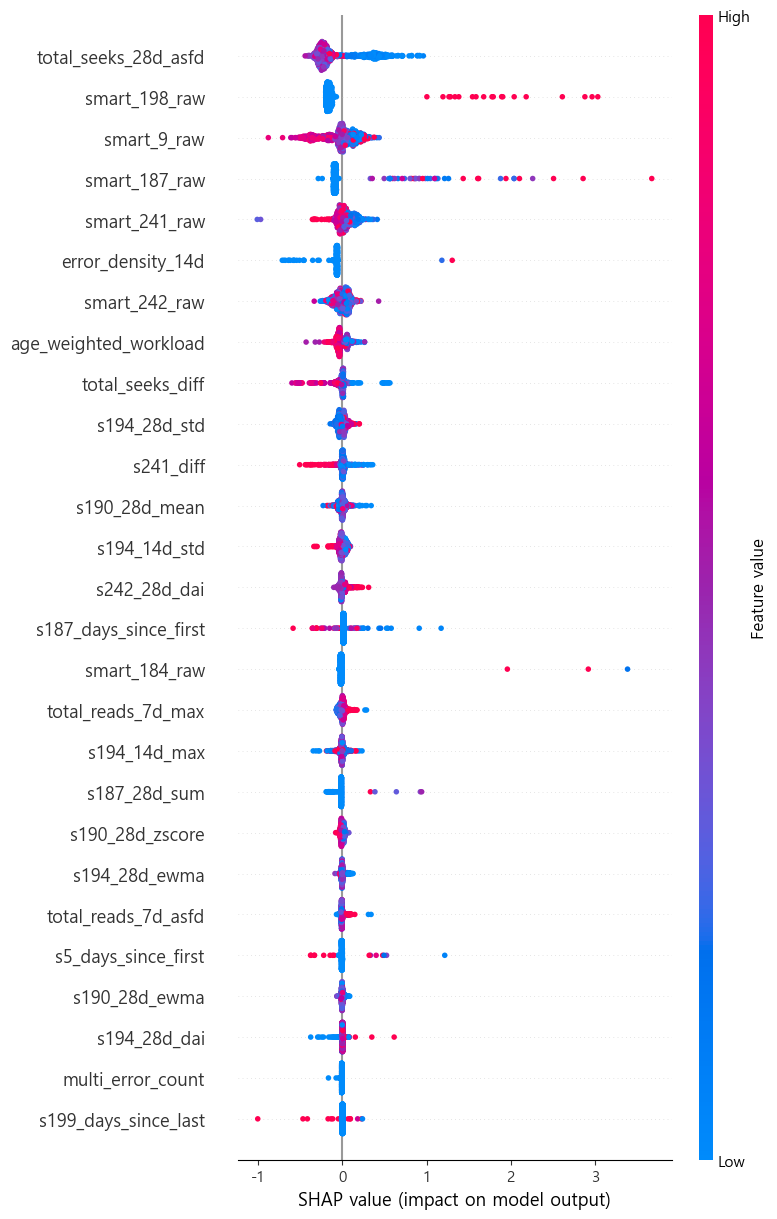

In [10]:
# src.train_core 내장 함수를 활용하여 SHAP 계산 및 시각화
plot_shap_importance(
    models=models, 
    df=df_val_tune, 
    feature_cols=FEATURE_COLS, 
    sample_size=1000, 
    seed=cfg.SEED
)